In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import itertools

In [3]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(), #added augmentation
    transforms.RandomVerticalFlip(), #added augmentation
    transforms.RandomRotation(15), #added augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5], std = [0.5])
])

In [4]:
dataset = datasets.ImageFolder('../astro_dataset', transform = transform)

In [5]:
print(dataset.classes)
print(dataset.class_to_idx)

['galaxy', 'star']
{'galaxy': 0, 'star': 1}


In [6]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

In [7]:
gen = torch.Generator().manual_seed(206265)
train_data, val_data = random_split(dataset, [train_size, val_size], generator=gen)

In [8]:
train_loader = DataLoader(train_data, batch_size = 32, generator=gen, shuffle=True)
val_loader = DataLoader(val_data, batch_size = 32, generator = gen, shuffle=True)

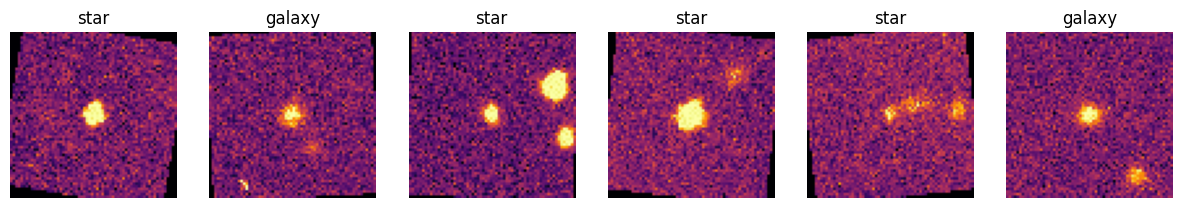

In [9]:
def denormalize(img):
    return img * 0.5 + 0.5

batch, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize = (15, 3))
for i in range(6):
    axes[i].imshow(denormalize(batch[i, 0, :, :].numpy()), cmap = 'inferno')
    axes[i].set_title(dataset.classes[labels[i]])
    axes[i].axis('off')
plt.show()

In [10]:
len(train_data), len(val_data)

(3188, 798)

In [11]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5) #1x64x64 -> 6x60x60
        self.pool1 = nn.MaxPool2d(2) #6x60x60 -> 6x30x30
        self.conv2 = nn.Conv2d(6, 12, 3) #6x30x30 -> 12x28x28
        self.pool2 = nn.AvgPool2d(2) #12x28x28 -> 12x14x14
        self.conv3 = nn.Conv2d(12, 16, 3) #12x14x14 -> 16x12x12
        self.pool3 = nn.MaxPool2d(2) #16x12x12 -> 16x6x6 = 576
        self.dropout = nn.Dropout(0.3) #added dropout here
        self.lin1 = nn.Linear(16*6*6, 64) #576 -> 64
        self.lin2 = nn.Linear(64, 1) #64 -> 1
    
    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x))) #added relu here
        x = self.pool2(torch.relu(self.conv2(x)))
        x = torch.flatten(self.pool3(self.conv3(x)), 1, -1)
        x = torch.relu(self.lin1(x))
        x = self.dropout(x)
        return self.lin2(x)[...,0]


In [12]:
cnn_model = CNN()

In [13]:
@torch.no_grad()
def get_stats(dataloader, criterion, num_batches = 10):
    cnn_model.eval()
    total_loss = 0
    total_correct = 0
    total_count = 0
    for batch, labels in itertools.islice(dataloader, num_batches):
        logits = cnn_model(batch)
        loss = criterion(logits, labels.float())
        total_loss += loss.item() * batch.shape[0]
        total_correct += (torch.abs(labels - torch.sigmoid(logits)) < 0.5).sum().item()
        total_count += batch.shape[0]
    
    cnn_model.train()
    return total_loss / total_count, total_correct / total_count

In [14]:
n_galaxy = 942
n_star = 3044

In [15]:
optimizer = torch.optim.Adam(cnn_model.parameters(), 1e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([n_galaxy / n_star]))
ITERS = len(train_loader)

train_accuracy = []
train_losses = []
val_accuracy = []
val_losses = []
EPOCHS = 200
for epoch in range(EPOCHS):
    cnn_model.train()
    for iter, (batch, labels) in enumerate(train_loader):
        logits = cnn_model(batch)
        loss = criterion(logits, labels.float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    tr_loss, tr_acc = get_stats(train_loader, criterion, num_batches=len(train_loader))
    val_loss, val_acc = get_stats(val_loader, criterion, num_batches=len(val_loader))
    train_losses.append(tr_loss)
    train_accuracy.append(tr_acc)
    val_losses.append(val_loss)
    val_accuracy.append(val_acc)
    if epoch%10 == 0 or epoch == EPOCHS - 1:
        print(f'Epoch {epoch}/{EPOCHS}:')
        print('-'*50)
        print(f'TRAIN: Loss {tr_loss}, Accuracy {tr_acc * 100}%')
        print(f'VAL: Loss {val_loss}, Accuracy {val_acc * 100}%')


Epoch 0/200:
--------------------------------------------------
TRAIN: Loss 0.32724045316128986, Accuracy 66.12296110414053%
VAL: Loss 0.3242907757896529, Accuracy 67.91979949874687%
Epoch 10/200:
--------------------------------------------------
TRAIN: Loss 0.2788395877165657, Accuracy 68.13048933500627%
VAL: Loss 0.28196048056870177, Accuracy 68.92230576441104%
Epoch 20/200:
--------------------------------------------------
TRAIN: Loss 0.24166186798920147, Accuracy 71.86323713927227%
VAL: Loss 0.24249847774816335, Accuracy 73.1829573934837%
Epoch 30/200:
--------------------------------------------------
TRAIN: Loss 0.21836533903178187, Accuracy 76.97616060225847%
VAL: Loss 0.22206883408820122, Accuracy 77.31829573934837%
Epoch 40/200:
--------------------------------------------------
TRAIN: Loss 0.2154254770675298, Accuracy 81.24215809284819%
VAL: Loss 0.2184684688136691, Accuracy 82.58145363408521%
Epoch 50/200:
--------------------------------------------------
TRAIN: Loss 0.20

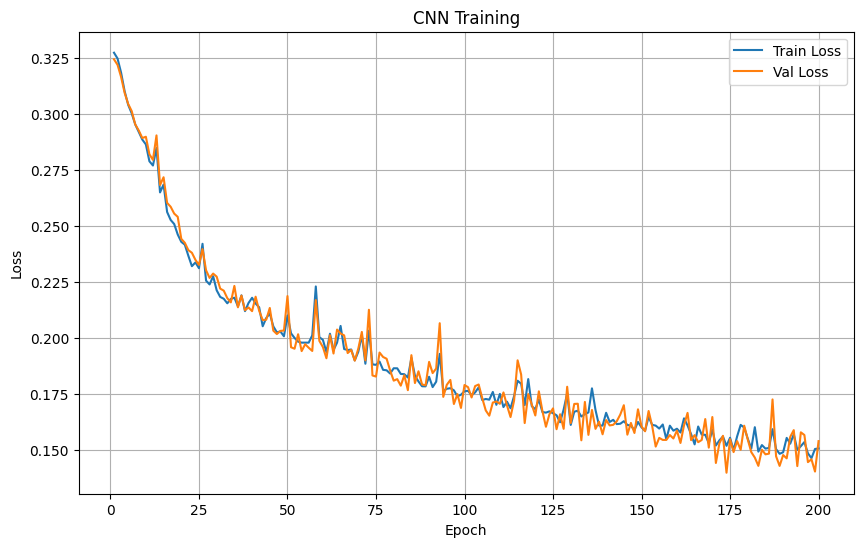

In [16]:
plt.figure(figsize = (10, 6))
plt.title('CNN Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(torch.arange(len(train_losses)) + 1, train_losses, label = 'Train Loss');
plt.plot(torch.arange(len(val_losses)) + 1, val_losses, label = 'Val Loss');
plt.grid()
plt.legend()
plt.show()

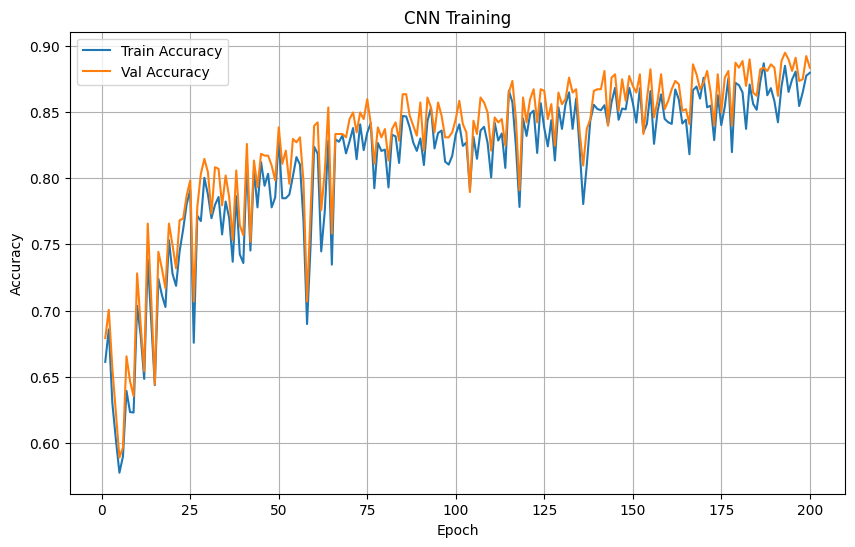

In [17]:
plt.figure(figsize = (10, 6))
plt.title('CNN Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(torch.arange(len(train_losses)) + 1, train_accuracy, label = 'Train Accuracy');
plt.plot(torch.arange(len(val_losses)) + 1, val_accuracy, label = 'Val Accuracy');
plt.grid()
plt.legend()
plt.show()

              precision    recall  f1-score   support

      galaxy       0.74      0.82      0.77       185
        star       0.94      0.91      0.93       613

    accuracy                           0.89       798
   macro avg       0.84      0.86      0.85       798
weighted avg       0.89      0.89      0.89       798



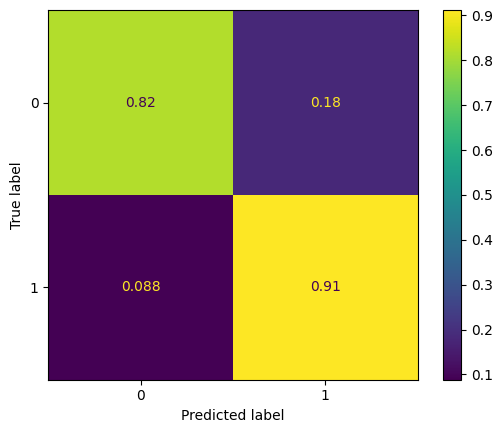

In [18]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

cnn_model.eval()
all_preds = []
all_labels = []
all_logits = []
with torch.no_grad():
    for images, labels in val_loader:
        logits = cnn_model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()
        all_logits.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['galaxy', 'star']))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, normalize='true');

In [ ]:
from sklearn.metrics import precision_recall_curve

probs = torch.sigmoid(torch.tensor(all_logits))
precisions, recalls, thresholds = precision_recall_curve(all_labels, probs, pos_label=0)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[f1_scores[:-1].argmax()]
print(f"Оптимальный порог: {best_threshold}")

Оптимальный порог: 0.5000948905944824
